In [1]:
from IPython.display import Image

# 7장. Neural Network

본 과목에서 DL의 방법적인 기초 원리인 신경망에 대하여 배운다. 
- 신경망 유래 
- 신경망 구조와 동작
- 신경망 학습 방법
- 응용예

## 1. 학습기반 방법론 





### 1) 규칙기반 방법론 
- 사람이 데이터를 관찰하여 규칙(pattern)을 파학하고, 이를 수학과 알고리즘 (rule)으로 만들어 사용
      - 예를 들어, Canny Edge 를 생각해보자. 
  1. 사람이 에지라고 느끼는 곳의 화소를 보니 화소값이 크게 변화하는 곳이네 = > 1차 미분의 차이가 큰 화소가 에지:(성능: 50 %)
  2. 에지라고 추정한 점들을 중 잘못된 것을 보니 그 한화소만 값이 큰 경우가 많이 있네 =>  smoothing을 하여 제거하게 처리 (sobel): (성능: 70%)
  3. 에지로 판단된 곳을 보니 뭉쳐 있는데, 같은 방향인 것이네 => NMS 을 적용: (성능 : 80%)
  4. 중간에 끊어지는 것들을 보니 미분값이 조금 작지만 주위에 에지 화소가 연결되있네 => Hysteris를 적용: (성능: 90%)
  
- **어려운점/한계**: 실제로 적용해 보면 경우가 매우 다양함. 모든 경우를 IF-ELSE 처리가 어려움. 
   - 앞서 1, 2, 3, 4로 한후에도 여전히 완벽하지 않음. 
   - 점점 더 해결이 어려워짐. (90%에서 잘 안올라감, 경우를 다 파학하기 조차 어려움)
   - 이게 정말 맞는 방향일까?

### 2) 학습 (데이터) 기반 방법론

- 이런 경우를 컴퓨터가 직접 알아내서 동작하게 하는 방법은 없을까? 

    - 경우(pattern)를 파학하기 위해서는 예제 즉, data 가 많이 필요함.
    - 또한 학습 (성능이 향상되는 과정)을 하기위한 방법론도 중요함.
    - 수십년간 다양한 방법이 제한됨: e.g. Decision Tree, Forest-tree, 신경망, SVM (Support vector machine)등
    - 신경망방식은 몇차례 고비를 넘기면서 성장하여 2010년이후에 두각을 나타냄.

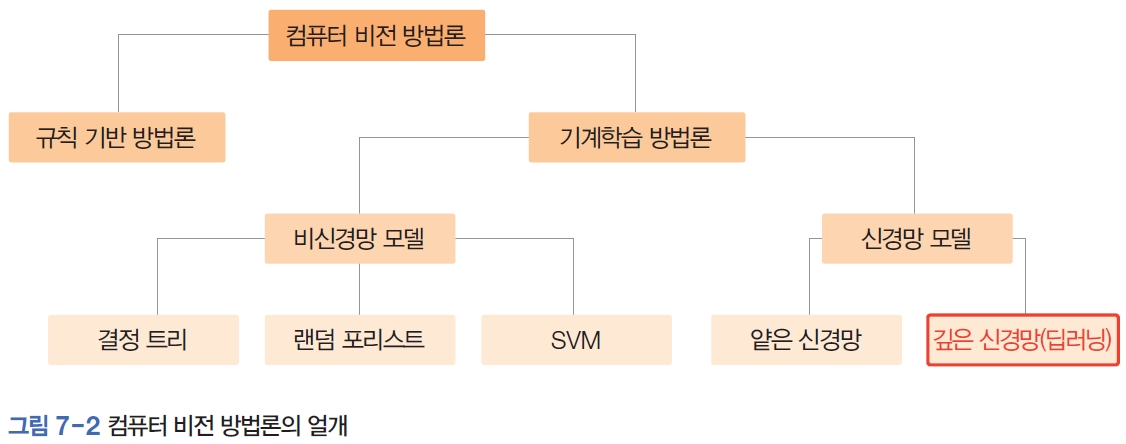

In [2]:
Image("그림 7-2.jpg", width=640)

## Note 용어

- 인공지능 (AI), 머신러닝(ML), Deep Learning 이라는 말이 혼용되어 사용되는데.
- 명확히 하자면 DL $\subset$ NN  $\subset$  ML $\subset$ AI 라고 해야한다. 방식의 범주에서
- IT용어를 접할 때 주의해야할 것이 그것이 기술/방식을 의미하는 지 제공하는 서비스를 의미하는지를 구분 해야하고 가끔씩 동일하거나 유사한 기술을 상업적인 용도에서 Fancy 하게 만들어 제공하는 경우도 있음에 유의 해야함.
- 이런 맥락에서,  DL은 NN의 상업적인 표현이라고 볼 수도 있고, Narrow NN에 대한 기술적이 차이를 의미할 수도. 



### 2. 기계학습 절차 

#### 1) 모델

- 수학적으로는 보통 함수 또는 순차적인 알고리즘
    - 일반 함수인 경우:  $y = f(x)$ 
    - 순차 알고리즘인 경우:  $ y_n = f(x_n, y_{n-1}) 

- 이 함수가 확정된 형태가 아니고, 일반적인 형태의 함수 집합
    - 구체적인 동작을 결정하는 파라메터는 미정인 상태임
    - 예) 
        - Taylor 급수:  $ f(x) = \sum_{n=0, \cdots} c_n x^n $
        - Fourier 급수: $ f(x) = \sum_{n=0, \cdots} ( a_n sin(2 \pi n x) +  b_n sin(2 \pi n x) ) $
                  
   - 선형 모델 vs 비선형 모델 그리고 합성 함수      
      - 수학적으로 해석이 용이한 선형모델 (Y = A X + B)을 초기에 사용하였으나, 성능적 한계에 다다름.     
      - 비선형 모델이 사용되기 시작함 (Y = A X*X  +  B X + C,  Y = f( A X + B))    
      - *노트* 선형함수로는 합성함수를 만들어도 여전히 선형 함수가 됨. 
          - $ f \cdot  g (x) = h (x) $에서 $f(x)$와 $g(x)$가 선형이면 $h(x)$도 선형   
      
#### 2) 데이터

- 이 정해지지 않은 모델 변수를 결정하기 위해서는 데이터 $ \{(x, y) \}$ 이 필요.
- 또한 얼마나 실제 함수 $f( \cdot )$을 근사화 했는지에 대한 기준이 필요 (loss 라고 표현, 보통 MSE를 사용)
- 학습 (이 파라메터들 조정하여 보다 좋은 성능이 나오도록, Loss가 줄어들더록 하는 과정.
    - 선형 근사화인 Taylor 급수나 Fourier 급수는 한번에 값을 계산 할 수 있음
    - 비선형 합성 함수 (계층이 많이 싸인)나 일반적인 경우는 이를 한번에 구할 방법이 없음.
    
#### 3) 모델의 성능에 미치는 요소  

 - 효과적인 구조/모델
 - 많고 좋은 데이터
 - loss 정의

### 기계 학습 방법  

- 데이터 수집, 모델 선택, 학습, 예측(적용)의 단계를 거침. 

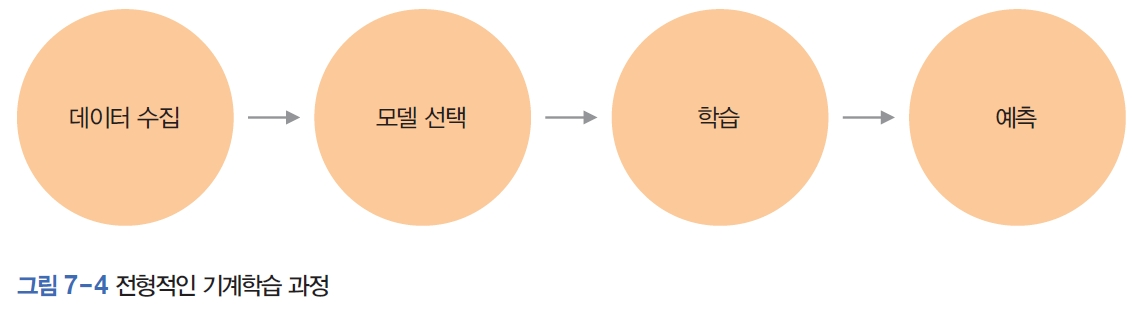

In [6]:
Image("그림 7-4.jpg", width=720)

### 3. 컴퓨터 비젼 관점

- 컴퓨터 비젼에서 해결하고 싶어하는 대표적인 문제들 
    - 분류, 검출, 인식, 분할 등의 세부 기능 
    - 최종적인 목표는 장면을 말로 풀어서 설명하는 것(captioning)이라고 볼 수 있음

- 방법 
    - 이미지 확보 
    - 이미지에 정답을 정함 (annotation): 일반적으로 사람이나 반자동으로 하게됨 (2000년이후부터 사람들이 디지털화 및 인터넷 확산을 통해 이미지양이 많아 지고 이를 바탕으로 대규모 데이터 셋을 구성하기 시작. PASCAL VOC, IMAGENET 등)   
    - 해당 문제를 해결할 만한 구조를 제시 (많은 이론과 경험이 필요 함)
    - 컴퓨터 라이브러리를 (Pytorch 등) 사용하여 학습
    - 실제 데이터를 적용 (또한 실제 동작 환경에 맞게 시스템을 최적화, TensorRT 등)

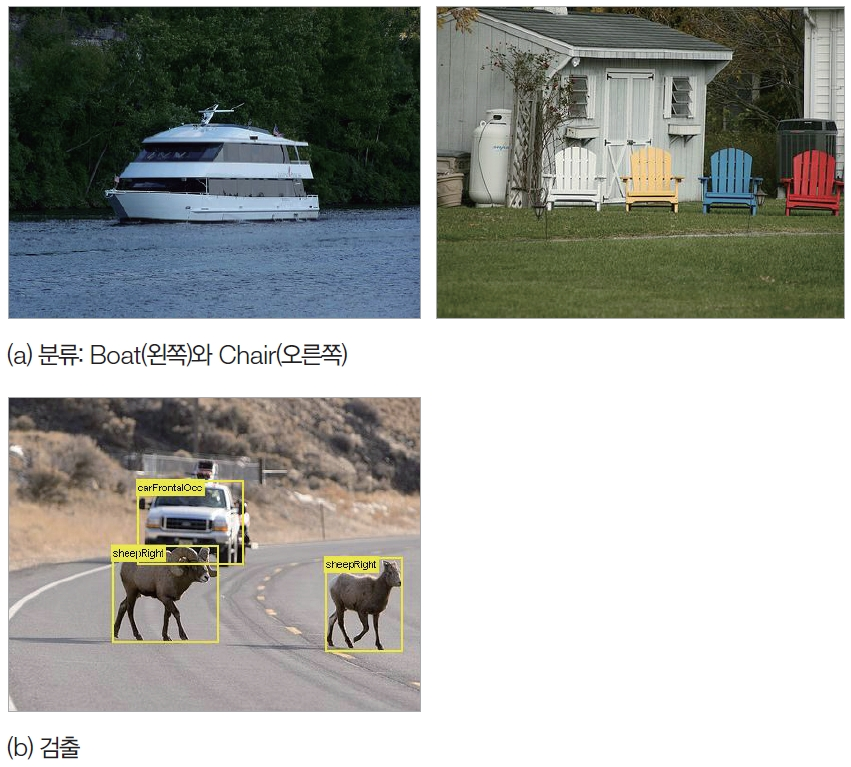

In [8]:
Image("그림 7-5(1).jpg", width=480)

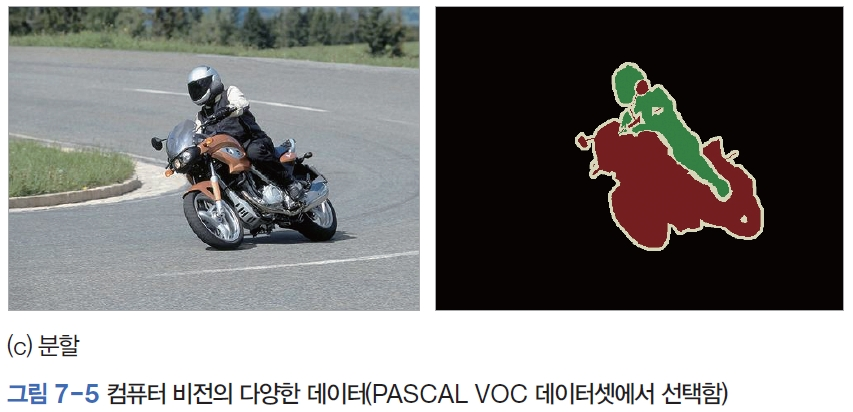

In [9]:
Image("그림 7-5(2).jpg", width=480)

## 끝